In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from ale_py.vector_env import AtariVectorEnv
import cv2
import numpy as np
from IPython.display import clear_output, display
import os
os.environ.pop("MPLBACKEND", None) 
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
print(matplotlib.get_backend())

# Deep Q-Network (DQN) Training Notebook
This notebook implements DQN for Atari Assault using PyTorch and ALE.

Implementation summary:
- Build a CNN-based Q-network to estimate action values Q(s, a).
- Use a replay buffer to decorrelate samples and improve data efficiency.
- Use a target network to stabilize temporal-difference targets.
- Train with epsilon-greedy exploration and periodically save checkpoints.
- Plot reward curves (raw + moving average) to monitor learning progress.

In [ ]:
class DeepQNetwork(nn.Module):
    def __init__(self, num_stack, num_action):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=num_stack, out_channels=32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1)
        self.lin1 = nn.Linear(3136, 512) 
        self.lin2 = nn.Linear(512, num_action)
    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.relu(self.conv2(X))
        X = F.relu(self.conv3(X))
        X = torch.flatten(X, start_dim=1) 
        X = F.relu(self.lin1(X))
        return self.lin2(X)

In [55]:
class ReplayBuffer:
    def __init__(self, N):
        self.N = N
        self.buffer = [None] * N
        self.pos = 0
        self.size = 0

    def add(self, state, action, reward, next_state, done):
        self.buffer[self.pos] = (state, action, reward, next_state, done)
        self.pos = (self.pos + 1) % self.N
        self.size = min(self.size + 1, self.N)

    def sample(self, batch_size):
        indices = np.random.choice(self.size, batch_size, replace=False)
        batch = [self.buffer[i] for i in indices]
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones)

    def __len__(self):
        return self.size

In [ ]:
class DQNAgent:
    def __init__(self, name, num_envs, num_stack):
        self.envs = AtariVectorEnv(
            game=name,
            num_envs=num_envs,
            stack_num=num_stack
        )
        self.num_envs = num_envs
        self.rewards = [[] for _ in range(num_envs)]  # rewards[env_id][epoch]
        self.epochs = []
        self.timestep = 0
        self.live_fig = None
        self.live_ax = None

    def moving_average(self, values, window=50): # smooth the learning curve
        if len(values) == 0:
            return np.array([]), np.array([])
        arr = np.array(values, dtype=np.float32)
        if len(arr) < window:
            return np.arange(1, len(arr) + 1), arr
        kernel = np.ones(window, dtype=np.float32) / window
        smooth = np.convolve(arr, kernel, mode='valid')
        x = np.arange(window, len(arr) + 1)
        return x, smooth

    def init_live_plot(self):
        self.live_fig, self.live_ax = plt.subplots(figsize=(24, 12))
        self.live_ax.set_xlabel('Epochs')
        self.live_ax.set_ylabel('Rewards')
        self.live_ax.set_title('Live Rewards over Epochs')

    def update_live_plot(self, smooth_window=50): # plot learning curve dynamically
        if self.live_fig is None or self.live_ax is None:
            self.init_live_plot()
        self.live_ax.clear()
        for env_id in range(self.num_envs):
            raw = self.rewards[env_id]
            self.live_ax.plot(self.epochs, raw, alpha=0.2, linewidth=1, label=f'env_{env_id}_raw')
            x_s, y_s = self.moving_average(raw, window=smooth_window)
            self.live_ax.plot(x_s, y_s, linewidth=2, label=f'env_{env_id}_ma{smooth_window}')
        self.live_ax.set_xlabel('Epochs')
        self.live_ax.set_ylabel('Rewards')
        self.live_ax.set_title('Live Rewards over Epochs (smoothed)')
        self.live_ax.legend()
        clear_output(wait=True)
        display(self.live_fig)

    def select_action(self, state, net, epsilon, device):
        if np.random.rand() < epsilon:
            return np.random.randint(0, net.lin2.out_features)
        else:
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0) / 255.0
            state_tensor = state_tensor.to(device)
            with torch.no_grad():
                q_values = net(state_tensor)
            return torch.max(q_values, dim=1).indices.item()
        
    def train_one_epoch(self, device, mini_batch_size, replay_buffer, net, target_net, loss, optimizer, gamma, save_root):
        states, _ = self.envs.reset()
        done = [False] * self.envs.num_envs
        total_rewards = [0] * self.envs.num_envs
        while not all(done):
            # Select actions
            actions = []
            for i in range(self.envs.num_envs):
                actions.append(self.select_action(states[i], net, self.epsilon, device))
            actions = np.array(actions)
            # Step the environment
            next_states, rewards, done, truncation, _ = self.envs.step(actions)
            done = done | truncation
            self.timestep += self.envs.num_envs
            # Store transitions in replay buffer
            for i in range(self.envs.num_envs):
                total_rewards[i] += rewards[i]
                replay_buffer.add(states[i], actions[i], rewards[i], next_states[i], done[i])
            states = next_states
            # Train the network
            if len(replay_buffer) >= 50000 and self.timestep % 4 == 0 :
                # Sample one minibatch for optimization
                batch_states, batch_actions, batch_rewards, batch_next_states, batch_dones = replay_buffer.sample(mini_batch_size)
                batch_states = torch.tensor(batch_states, dtype=torch.float32).to(device)
                batch_next_states = torch.tensor(batch_next_states, dtype=torch.float32).to(device)
                batch_actions = torch.tensor(batch_actions, dtype=torch.long).to(device)
                batch_rewards = torch.tensor(batch_rewards, dtype=torch.float32).to(device)
                batch_dones = torch.tensor(batch_dones, dtype=torch.float32).to(device)
                # Normalize pixel inputs
                batch_states /= 255.0
                batch_next_states /= 255.0
                q_values = net(batch_states).gather(1, batch_actions.unsqueeze(1)).squeeze(1)
                # Compute TD targets
                with torch.no_grad():
                    next_q_values = torch.max(target_net(batch_next_states), dim=1).values
                    target_q_values = batch_rewards + (1 - batch_dones) * gamma * next_q_values
                # Optimize online network
                loss_value = loss(q_values, target_q_values)
                optimizer.zero_grad()
                loss_value.backward()
                optimizer.step()
            # Linearly decay epsilon to 0.1 during the first 1,000,000 timesteps
            if self.timestep % 1000 == 0 and self.epsilon > 0.1:
                self.epsilon -= 0.0009
            # Synchronize target network every 10,000 timesteps
            if self.timestep % 10000 == 0:
                target_net.load_state_dict(net.state_dict())
            # Save checkpoints at fixed timestep intervals
            if self.timestep % 1000000 == 0:
                save_path = f"{save_root}/timesteps_{self.timestep}.pt"
                torch.save(net.state_dict(), save_path)
        return total_rewards    
            
    def train(self, device, frame, mini_batch_size, replay_buffer, net, target_net, loss, optimizer, gamma, save_root):
        import os
        os.makedirs(save_root, exist_ok=True)
        self.epsilon = 1.0
        epoch = 0
        frame = frame
        while self.timestep < frame :
            epoch += 1
            total_rewards = self.train_one_epoch(device, mini_batch_size, replay_buffer, net, target_net, loss, optimizer, gamma, save_root)
            for env_id in range(self.num_envs):
                self.rewards[env_id].append(total_rewards[env_id])
            self.epochs.append(epoch + 1)
            if epoch % 100 == 0:
                self.update_live_plot()
            print(f"timestep: {self.timestep}, epoch: {epoch}, epsilon: {self.epsilon:.4f}", end='\r', flush=True)

## Training Loop Notes
The `DQNAgent` class contains the full interaction-training loop.

Key design choices in this implementation:
- Action selection: epsilon-greedy for exploration/exploitation balance.
- Learning signal: TD target computed with a separate target network.
- Optimization timing: train every few environment steps after replay warm-up.
- Stability: synchronize target network periodically.
- Reproducibility: save model checkpoints at fixed timestep intervals.

In [62]:
learning_rate = 0.00025
gamma = 0.99
num_frame = 1e7
num_stack = 4
num_envs = 1
num_action = 7
mini_batch_size = 32
replay_memory_size = 1000000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [63]:
net = DeepQNetwork(num_stack=num_stack, num_action=num_action)
net = net.to(device)
target_net = DeepQNetwork(num_stack=num_stack, num_action=num_action)
target_net = target_net.to(device)
target_net.load_state_dict(net.state_dict())
optimizer = torch.optim.RMSprop(net.parameters(), lr=learning_rate, alpha=0.95, eps=0.01)
loss = nn.SmoothL1Loss()
replay_buffer = ReplayBuffer(N=replay_memory_size)
agent = DQNAgent(name="assault", num_envs=num_envs, num_stack=num_stack)

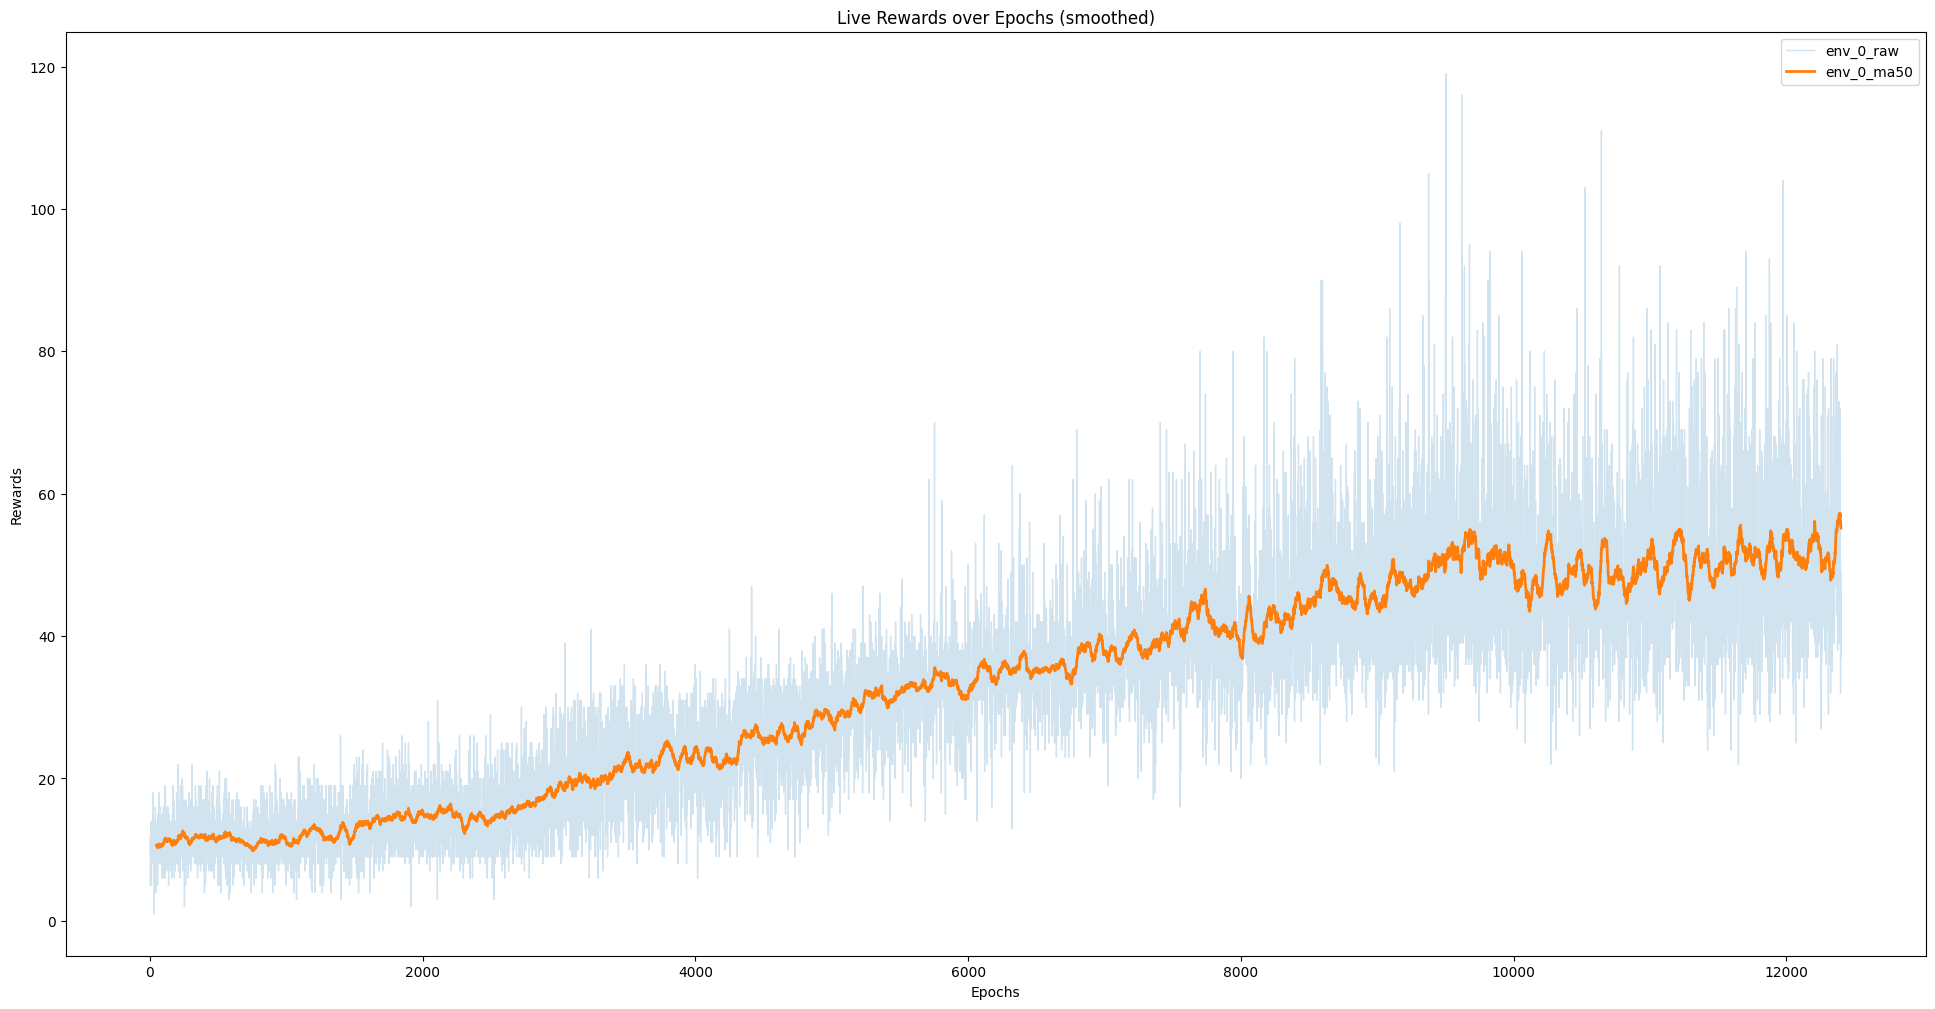

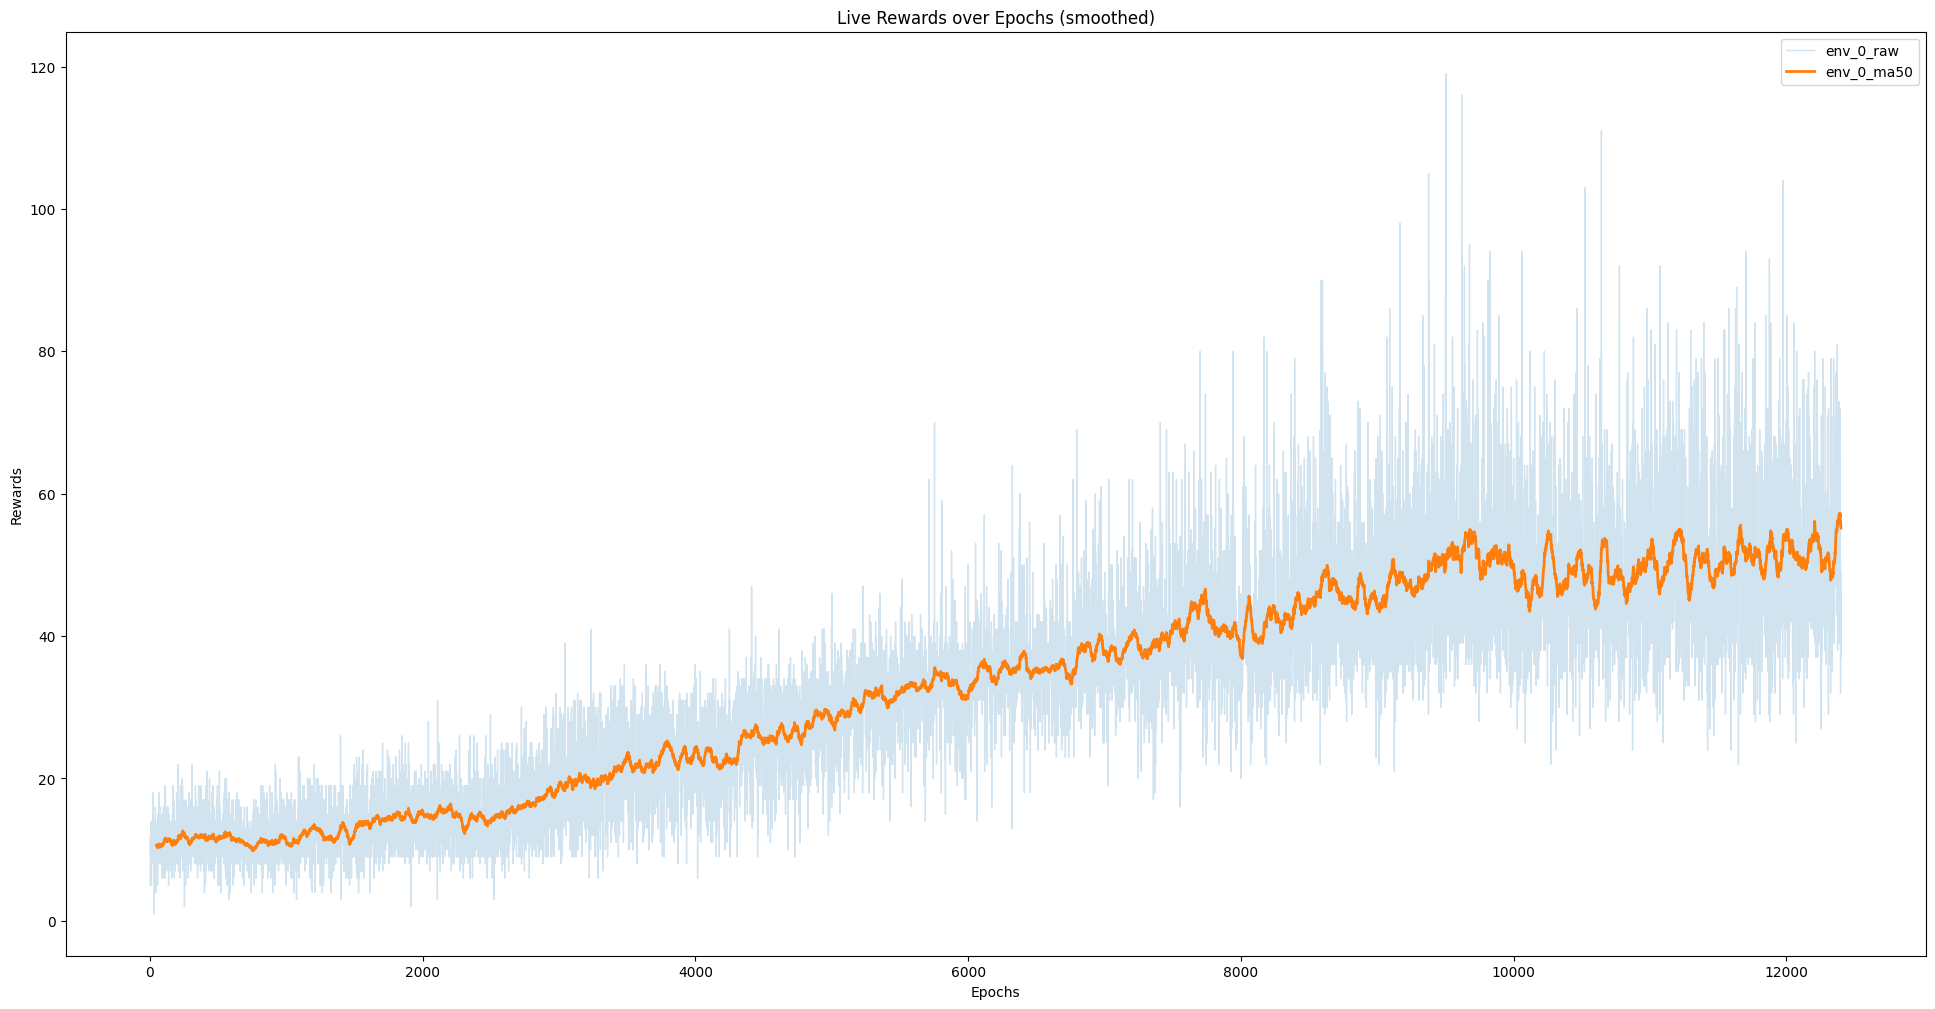

In [ ]:
agent.train(device=device,
            frame=num_frame, 
            mini_batch_size=mini_batch_size, 
            replay_buffer=replay_buffer, 
            net=net, 
            target_net=target_net, 
            loss=loss, 
            optimizer=optimizer, 
            gamma=gamma, 
            save_root="../models/dqn"
            )